In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import time

# 1. Cargar resultados de nuestra estrategia (del NB 04)
strat_results = pd.read_csv('Datos/backtest_results_with_costs.csv', index_col=0, parse_dates=True)
strat_log_returns = np.log(strat_results['TotalValue'] / strat_results['TotalValue'].shift(1)).dropna()

# 2. Cargar universo de precios de ejecución
# Necesitamos los precios CLOSE mensuales para calcular retornos
exec_prices = pd.read_csv('Datos/momentum_execution_prices.csv', index_col=0, parse_dates=True)
exec_prices = exec_prices.loc['2015-01-01':]

spy_data = pd.read_csv('Datos/spy_benchmark.csv', index_col=0, parse_dates=True)
# Alinear SPY con las fechas exactas de la estrategia
benchmark_prices = spy_data.reindex(strat_results.index).ffill()
# Calcular los retornos logarítmicos del Benchmark (SPY)
benchmark_log_rets = np.log(benchmark_prices['SPY'] / benchmark_prices['SPY'].shift(1)).dropna()

# Filtramos columnas CLOSE para el cálculo de retornos del universo
close_cols = [c for c in exec_prices.columns if '_CLOSE' in c]
df_prices = exec_prices[close_cols].resample('ME').last()

# Calculamos matriz de retornos simples para la simulación
returns_mat = np.log(df_prices / df_prices.shift(1)).values.astype(np.float32)
n_dates, n_tickers = returns_mat.shape

print(f"✅ Universo preparado: {n_tickers} activos en {n_dates} meses.")

# Ejecución de la simulación
total_monos = 25_000_000 
batch_size = 100_000
n_assets = 20
cost_pct=0.0023

✅ Universo preparado: 1278 activos en 133 meses.


In [2]:
import numpy as np
import time

def procesar_lote_vectorial(returns_mat, factors, rng, cur_batch, n_assets, cost_pct, modo_historia=False):
    """
    Motor central que simula un lote de carteras.
    Si modo_historia=True, devuelve los retornos diarios de cada mono del lote.
    Si modo_historia=False, devuelve solo el retorno acumulado final (ahorra RAM).
    """
    n_dates = returns_mat.shape[0]
    
    if modo_historia:
        # Matriz temporal para guardar el día a día (solo la usaremos al graficar)
        salida_retornos = np.zeros((n_dates, cur_batch), dtype=np.float32)
    else:
        # Array simple para guardar la suma final
        salida_retornos = np.zeros(cur_batch, dtype=np.float32)
        
    for t in range(1, n_dates):
        avail_mask = ~np.isnan(returns_mat[t])
        avail_idx = np.where(avail_mask)[0]
        num_avail = len(avail_idx)
        
        if num_avail < n_assets: 
            continue
        
        # Selección aleatoria determinista
        idx = rng.integers(0, num_avail, size=(cur_batch, n_assets))
        
        # Corrección de colisiones (duplicados)
        while True:
            sorted_idx = np.sort(idx, axis=1)
            dups = sorted_idx[:, 1:] == sorted_idx[:, :-1]
            mask_collided = np.any(dups, axis=1)
            
            if not np.any(mask_collided):
                break
            
            num_collided = np.sum(mask_collided)
            idx[mask_collided] = rng.integers(0, num_avail, size=(num_collided, n_assets))

        real_indices = avail_idx[idx]
        
        # Cálculo financiero
        gross_factor = factors[t, real_indices].mean(axis=1)
        net_rets = gross_factor - (2 * cost_pct)
        
        daily_log_ret = np.log(net_rets)
        
        # Guardar en la estructura correspondiente según el modo
        if modo_historia:
            salida_retornos[t] = daily_log_ret
        else:
            salida_retornos += daily_log_ret
            
    return salida_retornos

In [ ]:
def simular_monos_vectorial(returns_mat, n_monkeys, batch_size):
    
    all_final_returns = np.zeros(n_monkeys, dtype=np.float32)
    monkey_seeds = np.zeros(n_monkeys, dtype=np.uint32)
    
    start_time = time.time()
    print(f"🚀 Iniciando simulación de {n_monkeys:,} monos en lotes de {batch_size:,}...")

    print("Precalculando factores históricos...")
    factors = np.exp(returns_mat).astype(np.float32)

    for b_start in range(0, n_monkeys, batch_size):
        b_end = min(b_start + batch_size, n_monkeys)
        cur_batch = b_end - b_start

        # 1. Semilla y generador del lote
        batch_seed = np.random.randint(0, 2**31 - 1)
        monkey_seeds[b_start:b_end] = batch_seed
        rng = np.random.default_rng(batch_seed)
        
        # 2. Invocamos al motor en modo de producción (modo_historia=False)
        batch_log_rets = procesar_lote_vectorial(
            returns_mat, factors, rng, cur_batch, n_assets, cost_pct, modo_historia=False
        )
        
        all_final_returns[b_start:b_end] = batch_log_rets
        
        elapsed = (time.time() - start_time)
        print(f"✅ {b_end:,} monos calculados... ({elapsed:.2f} s)")

    return all_final_returns, monkey_seeds

In [4]:
monkeys_final_rets, monkey_seeds = simular_monos_vectorial(returns_mat, n_monkeys=total_monos, batch_size=batch_size)

🚀 Iniciando simulación de 25,000,000 monos en lotes de 100,000...
Precalculando factores históricos...
✅ 100,000 monos calculados... (22.70 s)
✅ 200,000 monos calculados... (45.29 s)
✅ 300,000 monos calculados... (67.78 s)
✅ 400,000 monos calculados... (90.12 s)
✅ 500,000 monos calculados... (113.44 s)
✅ 600,000 monos calculados... (136.07 s)
✅ 700,000 monos calculados... (158.41 s)
✅ 800,000 monos calculados... (181.10 s)
✅ 900,000 monos calculados... (203.70 s)
✅ 1,000,000 monos calculados... (226.06 s)
✅ 1,100,000 monos calculados... (248.18 s)
✅ 1,200,000 monos calculados... (270.73 s)
✅ 1,300,000 monos calculados... (293.44 s)
✅ 1,400,000 monos calculados... (316.01 s)
✅ 1,500,000 monos calculados... (338.77 s)
✅ 1,600,000 monos calculados... (360.85 s)
✅ 1,700,000 monos calculados... (383.53 s)
✅ 1,800,000 monos calculados... (406.23 s)
✅ 1,900,000 monos calculados... (428.90 s)
✅ 2,000,000 monos calculados... (451.51 s)
✅ 2,100,000 monos calculados... (473.89 s)
✅ 2,200,000 mono

In [5]:
import os
import numpy as np

# Definimos las rutas de los archivos persistentes
path_rets = 'Datos/monkeys_final_rets.npy'
path_seeds = 'Datos/monkey_seeds.npy'

# Comprobamos si AMBAS variables existen en memoria tras ejecutar la simulación
if 'monkeys_final_rets' in locals() and 'monkey_seeds' in locals() and monkeys_final_rets is not None:
    # Si existen, las guardamos en disco
    np.save(path_rets, monkeys_final_rets)
    np.save(path_seeds, monkey_seeds)
    print(f"✅ Simulación guardada exitosamente en:\n  - {path_rets}\n  - {path_seeds}")
else:
    # Si no están en memoria, intentamos recuperarlas del disco
    if os.path.exists(path_rets) and os.path.exists(path_seeds):
        monkeys_final_rets = np.load(path_rets)
        monkey_seeds = np.load(path_seeds)
        print(f"📂 Variables cargadas desde el disco. Total monos: {len(monkeys_final_rets):,}")
    else:
        print("⚠️ No se encontraron las variables en memoria ni los archivos previos en disco. Debes ejecutar la simulación.")

# Calculamos el total de monos solo si las variables se cargaron/crearon correctamente
if 'monkeys_final_rets' in locals() and monkeys_final_rets is not None:
    total_monos = len(monkeys_final_rets)

✅ Simulación guardada exitosamente en:
  - Datos/monkeys_final_rets.npy
  - Datos/monkey_seeds.npy


In [6]:
import os
import numpy as np

# Definimos las rutas de los archivos persistentes
path_rets = 'Datos/monkeys_final_rets.npy'
path_seeds = 'Datos/monkey_seeds.npy'
# Si no están en memoria, intentamos recuperarlas del disco
if os.path.exists(path_rets) and os.path.exists(path_seeds):
    monkeys_final_rets = np.load(path_rets)
    monkey_seeds = np.load(path_seeds)
    print(f"📂 Variables cargadas desde el disco. Total monos: {len(monkeys_final_rets):,}")
else:
    print("⚠️ No se encontraron las variables en memoria ni los archivos previos en disco. Debes ejecutar la simulación.")

# Calculamos el total de monos solo si las variables se cargaron/crearon correctamente
if 'monkeys_final_rets' in locals() and monkeys_final_rets is not None:
    total_monos = len(monkeys_final_rets)

📂 Variables cargadas desde el disco. Total monos: 25,000,000


In [7]:
monkeys_final_rets.shape

(25000000,)

In [8]:
# --- Visualización de Percentiles ---

# 1. Convertir log-retornos a retornos simples
monkeys_simple_rets = np.exp(monkeys_final_rets)

# 2. Calcular percentiles
percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
perc_values = np.percentile(monkeys_simple_rets, percentiles)

print(f"Resultados de {total_monos:,} monos:")
for p, val in zip(percentiles, perc_values):
    print(f"Percentil {p}: {val:.2%}")

Resultados de 25,000,000 monos:
Percentil 0: 39.44%
Percentil 10: 94.80%
Percentil 20: 103.78%
Percentil 30: 110.81%
Percentil 40: 117.24%
Percentil 50: 123.61%
Percentil 60: 130.40%
Percentil 70: 138.15%
Percentil 80: 147.96%
Percentil 90: 163.13%
Percentil 100: 457.23%


Decil 1 (Mono #14788798)
Decil 2 (Mono #8838052)
Decil 3 (Mono #23923363)
Decil 4 (Mono #1195053)
Decil 5 (Mono #1156535)
Decil 6 (Mono #12966983)
Decil 7 (Mono #5112107)
Decil 8 (Mono #10378361)
Decil 9 (Mono #15069548)
Decil 10 (Mono #8488589)


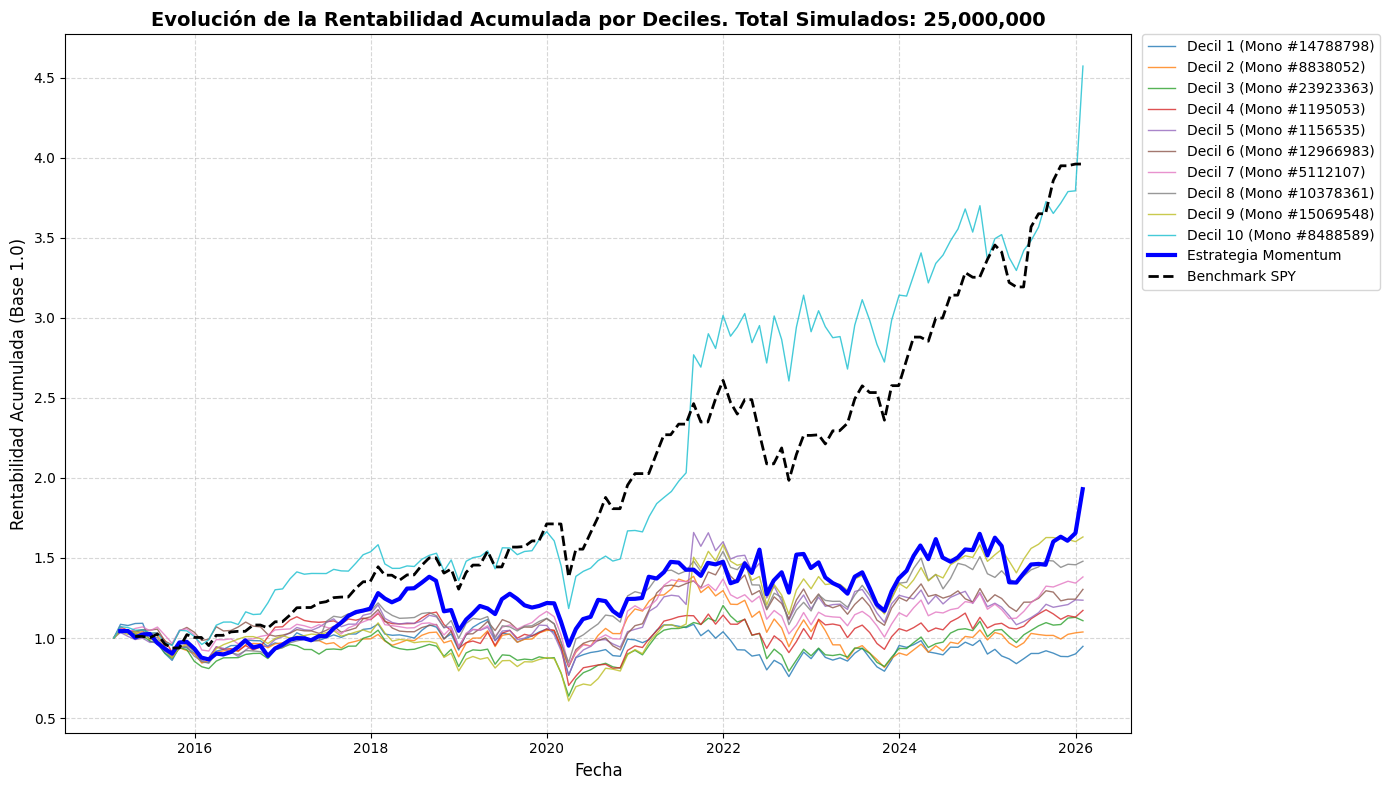

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Identificar los escenarios que representan cada decil
# Ordenamos los resultados finales para encontrar las posiciones de los deciles
sorted_indices = np.argsort(monkeys_final_rets)

# Obtenemos las posiciones (0 a N-1) en el array ordenado que corresponden al 10%, 20%... 100%
decile_indices = np.percentile(np.arange(len(monkeys_final_rets)), 
                               np.linspace(10, 100, 10)).astype(int)

# Estos son los IDs reales (0 a 1.000.000) de los monos que representan cada decil
decile_positions = sorted_indices[decile_indices]


# 2. Re-simular solo los escenarios seleccionados usando nuestra arquitectura de Semilla por Lote
def reconstruir_evolucion_mono(mono_id, monkey_seeds, returns_mat, batch_size=100_000):
    n_assets = 20
    cost_pct = 0.0023
    
    # 1. Identificar el lote y la posición local del mono
    b_start = (mono_id // batch_size) * batch_size
    b_end = min(b_start + batch_size, len(monkey_seeds))
    cur_batch = b_end - b_start
    local_id = mono_id - b_start 
    
    # 2. Reconstruir el generador exacto del lote original
    batch_seed = monkey_seeds[mono_id]
    rng = np.random.default_rng(batch_seed)
    factors = np.exp(returns_mat).astype(np.float32)
    
    # 3. Invocamos al motor en modo Historia (modo_historia=True)
    historia_lote = procesar_lote_vectorial(
        returns_mat, factors, rng, cur_batch, n_assets, cost_pct, modo_historia=True
    )
    
    # 4. Aislar la columna de nuestro mono y hacer la suma acumulada (cum_sum)
    mono_diario_logs = historia_lote[:, local_id]
    capital_path = np.exp(np.cumsum(mono_diario_logs))
    
    return capital_path


# 3. Generar la gráfica
plt.figure(figsize=(14, 8))

# Graficar los escenarios de los deciles
for i, monkey_pos in enumerate(decile_positions):
    label = f'Decil {i+1} (Mono #{monkey_pos})'
    print(label)
    evolucion = reconstruir_evolucion_mono(monkey_pos, monkey_seeds, returns_mat, batch_size=batch_size)
    plt.plot(df_prices.index, evolucion, label=label, linewidth=1, alpha=0.8)

# Graficar nuestra Estrategia de Momentum (del NB 04)
strat_cum_ret = np.exp(strat_log_returns.cumsum())
plt.plot(strat_cum_ret.index, strat_cum_ret, label='Estrategia Momentum', color='blue', linewidth=3)

# Graficar el Benchmark SPY
spy_cum_ret = np.exp(benchmark_log_rets.cumsum())
plt.plot(spy_cum_ret.index, spy_cum_ret, label='Benchmark SPY', color='black', linewidth=2, linestyle='--')

# Configuración estética
total_monos = len(monkeys_final_rets)
plt.title(f'Evolución de la Rentabilidad Acumulada por Deciles. Total Simulados: {total_monos:,}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rentabilidad Acumulada (Base 1.0)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10, borderaxespad=0.)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout() # Asegura que la leyenda fuera del gráfico no se corte
plt.show()

In [10]:
# Retorno acumulado real de nuestra estrategia
final_strat_ret = strat_log_returns.sum()

# Calcular percentiles de la simulación
p05 = np.percentile(monkeys_final_rets, 5)
median_monkeys = np.median(monkeys_final_rets)

print("\n--- 📊 RESULTADOS MONTE CARLO ---")
print(f"Retorno Final Estrategia (Log): {final_strat_ret:.4f}")
print(f"Mediana de los Monos (Log):     {median_monkeys:.4f}")


--- 📊 RESULTADOS MONTE CARLO ---
Retorno Final Estrategia (Log): 0.6574
Mediana de los Monos (Log):     0.2120
